<h1 align="center">Quick Commerce Data</h1>

The project features a GenAI-ready data pipeline that handles complex data cleaning (imputation of ratings and city data) and visualizes key performance
indicators (KPIs) like Average Order Value (AOV) and Partner Efficiency."

### Data Loading & Cleaning

In [32]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Data Loading

df = pd.read_csv(r"C:\Users\shivam vishwakarma\Downloads\quick_commerce_data_raw.csv")

In [34]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [35]:
# Checking Missing Value

df.isnull().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [36]:
df["City"].value_counts()

City
Hyderabad    79481
Delhi        79183
Kolkata      79174
Mumbai       79078
Amritsar     79074
Gurgaon      79004
Bengluru     78973
Haridwar     78958
Jaipur       78901
Noida        78869
Chennai      78725
Pune         78580
Name: count, dtype: int64

In [37]:
# City null value fill with the most requent city
# Filling Missing Value

df['City'] = df['City'].fillna("Hyderabad")

In [38]:
df.isnull().sum()

Order_ID                        0
Company                         0
City                            0
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [39]:
#Filling the Missing Value with the median

df["Items_Count"] = df["Items_Count"].fillna(df["Items_Count"].median())

In [40]:
df.isnull().sum()

Order_ID                        0
Company                         0
City                            0
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                     0
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [41]:
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2


In [42]:
df["Customer_Rating"] = df["Customer_Rating"].fillna(df["Customer_Rating"].mean())

In [43]:
df.isnull().sum()

Order_ID                        0
Company                         0
City                            0
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                     0
Product_Category                0
Payment_Method                  0
Customer_Rating                 0
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [44]:
df["Delivery_Partner_Rating"] = df["Delivery_Partner_Rating"].fillna(df["Delivery_Partner_Rating"].median)

In [45]:
df.isnull().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

In [46]:
#Checking the datatypes

df.dtypes

Order_ID                     int64
Company                     object
City                        object
Customer_Age                 int64
Order_Value                float64
Delivery_Time_Min          float64
Distance_Km                float64
Items_Count                float64
Product_Category            object
Payment_Method              object
Customer_Rating            float64
Discount_Applied             int64
Delivery_Partner_Rating     object
dtype: object

In [47]:
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2


In [48]:
df["Delivery_Partner_Rating"].dtype

dtype('O')

In [49]:
#Correcting the datatype
# using errors="coerce" for change only the type dont take extra else

df["Delivery_Partner_Rating"] = pd.to_numeric(df["Delivery_Partner_Rating"], errors="coerce")

In [50]:
df["Delivery_Partner_Rating"].dtype

dtype('float64')

In [51]:
df.dtypes

Order_ID                     int64
Company                     object
City                        object
Customer_Age                 int64
Order_Value                float64
Delivery_Time_Min          float64
Distance_Km                float64
Items_Count                float64
Product_Category            object
Payment_Method              object
Customer_Rating            float64
Discount_Applied             int64
Delivery_Partner_Rating    float64
dtype: object

In [52]:
# Checking duplicate values

df.duplicated().sum()

np.int64(0)

### Data Manipulation

In [53]:
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2


In [54]:
def Order_Segment(val):
    if val < 300:
        return "Low Value"
    elif val < 800:
        return "Mid Value"
    else:
        return "High Value"

In [55]:
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2


In [56]:
df["Speed_Index"] = df["Delivery_Time_Min"]/ df["Distance_Km"]

In [57]:
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Speed_Index
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,1.602506
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,1.541915


In [58]:
df["Is_Happy_Customer"] = df["Customer_Rating"].apply(lambda x: 1 if x > 4 else 0)

In [59]:
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Speed_Index,Is_Happy_Customer
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,1.602506,0
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,1.541915,0


### Market Share & Revenue by Company(Pie & Bar)

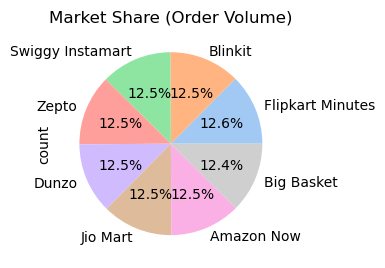

In [60]:
# Total Orders by Company

plt.subplot(1, 2, 1)
df['Company'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Market Share (Order Volume)')

plt.tight_layout()
plt.show()

In [61]:
# # Total Revenue per Company 

# plt.subplot(1, 2, 2)
# sns.barplot(x='Company', y='Order_Value', data=df, estimator=sum, hue='Company', palette='viridis', legend=False)
# plt.xticks(rotation=45)
# plt.title('Total Revenue Contribution')

# plt.tight_layout()
# plt.show()

In [62]:
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 2)
# sns.barplot(x='Company', y='Order_Value', data=df, estimator=sum, hue='Company', palette='viridis')

# # # Agar legend aa raha hai aur aapko use hatana hai, toh ye line likhein:
# # plt.legend([], frameon=False) 

# plt.xticks(rotation=45)
# plt.title('Total Revenue Contribution')

# plt.tight_layout()
# plt.show()

### Delivery Time Analysis (Box Plot)

In [64]:
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Speed_Index,Is_Happy_Customer
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,1.602506,0
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,1.541915,0


In [66]:
df.Delivery_Time_Min

0         19.182
1         19.644
2         16.910
3          5.864
4         12.470
           ...  
999995    17.806
999996    18.306
999997    17.590
999998    12.656
999999    17.670
Name: Delivery_Time_Min, Length: 1000000, dtype: float64

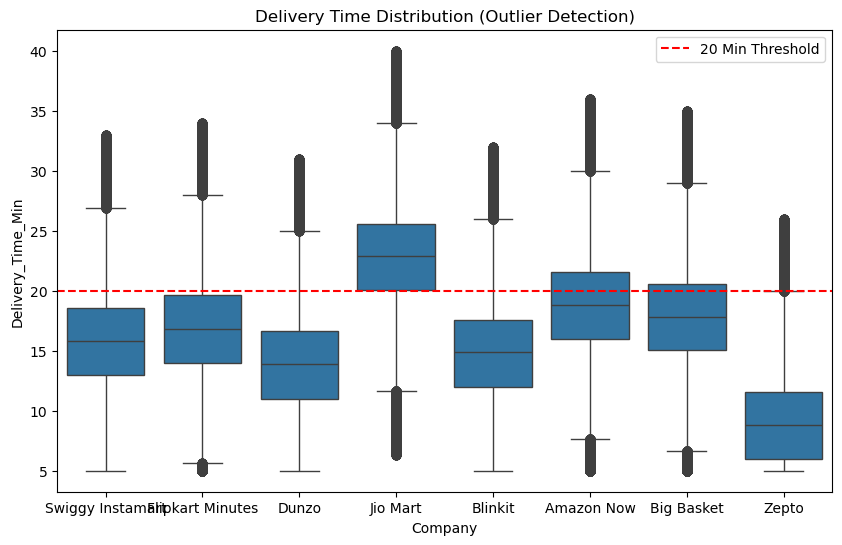

In [63]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Company', y='Delivery_Time_Min', data=df)
plt.axhline(20, color='red', linestyle='--', label='20 Min Threshold')
plt.title('Delivery Time Distribution (Outlier Detection)')
plt.legend()
plt.show()

### Correlation Heatmap (Relations)

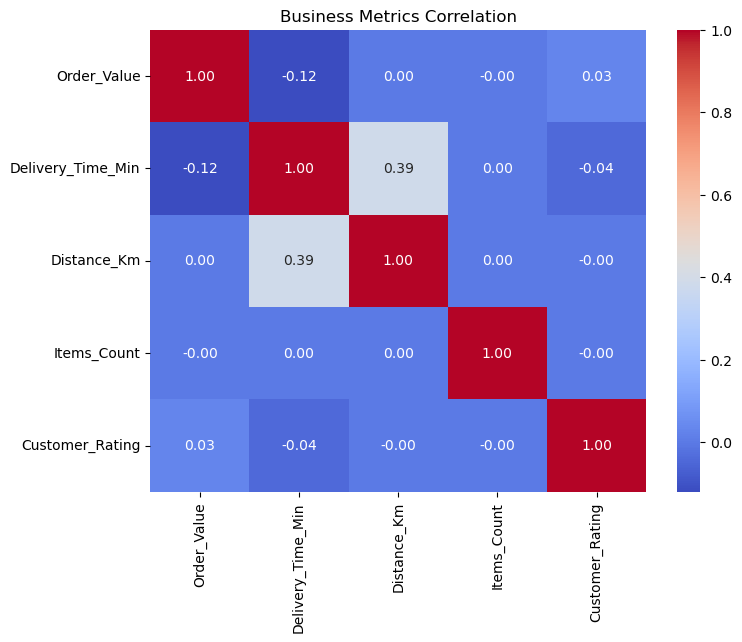

In [67]:
plt.figure(figsize=(8, 6))
correlation = df[['Order_Value', 'Delivery_Time_Min', 'Distance_Km', 'Items_Count', 'Customer_Rating']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Business Metrics Correlation')
plt.show()

### Product Category vs Revenue (Bar Chart)

C:\Users\shivam vishwakarma\AppData\Local\Temp\ipykernel_6848\1367847426.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Product_Category', data=df, order=df['Product_Category'].value_counts().index, palette='magma')


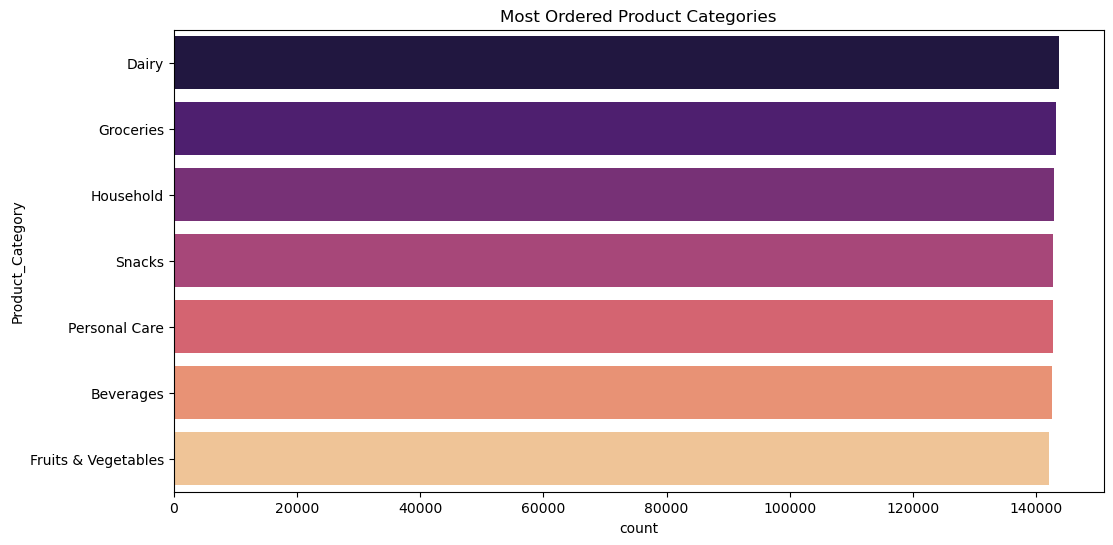

In [70]:
plt.figure(figsize=(12, 6))
sns.countplot(y='Product_Category', data=df, order=df['Product_Category'].value_counts().index, palette='magma')
plt.title('Most Ordered Product Categories')
plt.show()

In [ ]:
#future warning is want to say in the future seaborn library in (v0.14.0) version it will not work 